# Tool catalog: notebook outputs and canvas

Run these cells in order in a disposable JupyterLab project with its live kernel and selected ChatGPT connection. The PNG, SVG, text, and structured outputs below are generated here and are actual live notebook outputs. The early `read_selection` cells show the honest empty state; the final selected-text section shows how to read text after focusing its editor while the request is pending. Canvas controls depend on whether JupyterLab keeps the plain HTML canvas in its output; an unsupported result is honest and does not justify substituting a fake canvas. Wait for each browser receipt before inspecting it. The final AI questions request real tool calls against these exact output cells.


In [1]:
from io import BytesIO
from pathlib import Path
import hashlib
from PIL import Image as PILImage
from IPython.display import display, Image, SVG, HTML, Javascript
from nbinlineai.tools import (read_notebook_view, read_selection, list_outputs, read_output, export_output, list_canvases, capture_canvas, export_canvas, start_canvas, capture_notebook_region, operation_status, release_media, stop_source)
image = PILImage.new('RGB', (8, 8), '#d4402f')
stream = BytesIO(); image.save(stream, format='PNG')
PNG_BYTES = stream.getvalue()
SVG_MARKUP = '<svg xmlns="http://www.w3.org/2000/svg" width="24" height="18"><rect width="24" height="18" fill="#2542a3"/></svg>'
print('Disposable PNG and original SVG are ready; no file was saved.')

Disposable PNG and original SVG are ready; no file was saved.


In [2]:
display(Image(data=PNG_BYTES))

In [3]:
print('Existing output text: red square and blue vector')

Existing output text: red square and blue vector


In [4]:
display(SVG(data=SVG_MARKUP))

### Existing structured output

This small data-resource MIME output is read from the live model; exporting it returns exact UTF-8 JSON bytes and may save a new `.json` file. No renderer or code execution is triggered by discovery.


In [5]:
DATA_RESOURCE = {'schema': {'fields': [{'name': 'color', 'type': 'string'}]}, 'data': [{'color': 'é😀'}]}
display({'application/vnd.dataresource+json': DATA_RESOURCE, 'text/plain': 'One color row'}, raw=True)


One color row

## Inspect the existing notebook

The first five tools work with live model state. They do not run an output cell for you. The IDs below belong to this copied notebook.

In [6]:
view = read_notebook_view()

In [7]:
print('Notebook view:', view.status, view.result, view.error)


Notebook view: completed {'active_cell_id': 'view-call', 'active_cell_index': 8, 'selected_cell_ids': ['view-call'], 'selected_truncated': False, 'visible': {'first': 'output-vector', 'last': 'outputs-list-inspect', 'count': 10}, 'mode': 'command', 'cell_count': 67} None


In [8]:
selection = read_selection(max_chars=120)

In [9]:
print('Selection:', selection.status, selection.result, selection.error)
print('An empty selection is expected if no text was selected in this editor.')


Selection: completed {'cell_id': None, 'text': '', 'truncated': False} None
An empty selection is expected if no text was selected in this editor.


In [10]:
raster_listing = list_outputs('output-raster')
text_listing = list_outputs('output-text')
vector_listing = list_outputs('output-vector')

In [11]:
for label, receipt in [('raster', raster_listing), ('text', text_listing), ('vector', vector_listing)]: print(label, receipt.status, receipt.result, receipt.error)
raster_ref = raster_listing.result['outputs'][0] if raster_listing.result else None
text_ref = text_listing.result['outputs'][0] if text_listing.result else None
vector_ref = vector_listing.result['outputs'][0] if vector_listing.result else None

raster completed {'outputs': [{'cell_id': 'output-raster', 'output_id': '6b859082defe8b90b9bc44def78142b1', 'revision': 0, 'mime_types': ['image/png', 'text/plain'], 'output_type': 'display_data'}], 'next_cursor': None} None
text completed {'outputs': [{'cell_id': 'output-text', 'output_id': '55dc7920f34e5de633de570e694c7a46', 'revision': 0, 'mime_types': ['text/plain'], 'output_type': 'stream'}], 'next_cursor': None} None
vector completed {'outputs': [{'cell_id': 'output-vector', 'output_id': '9be5ddd1fd79af71a0132fb396adbcbf', 'revision': 0, 'mime_types': ['text/plain', 'image/svg+xml'], 'output_type': 'display_data'}], 'next_cursor': None} None


In [12]:
text_read = read_output(text_ref['cell_id'], text_ref['output_id'], text_ref['revision'], max_chars=120) if text_ref else None

In [13]:
print(text_read.status, text_read.result, text_read.error) if text_read else print('List the text output first.')

completed {'cell_id': 'output-text', 'output_id': '55dc7920f34e5de633de570e694c7a46', 'revision': 0, 'mime': 'text/plain', 'text': 'Existing output text: red square and blue vector\n', 'start': 0, 'next_start': None, 'total_chars': 49} None


In [14]:
raster_export = export_output(raster_ref['cell_id'], raster_ref['output_id'], raster_ref['revision']) if raster_ref else None
vector_export = export_output(vector_ref['cell_id'], vector_ref['output_id'], vector_ref['revision'], mime='image/svg+xml') if vector_ref else None

Raster: completed PngImageFile (8, 8) None
SVG: completed True None


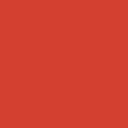

In [15]:
print('Raster:', raster_export.status, type(raster_export.result).__name__, getattr(raster_export.result, 'size', None), raster_export.error) if raster_export else print('List raster output first.')
print('SVG:', vector_export.status, vector_export.result == SVG_MARKUP, vector_export.error) if vector_export else print('List SVG output first.')
if raster_export and raster_export.status == 'completed':
    display(raster_export.result.resize((128, 128)))


In [16]:
data_listing = list_outputs('output-data')


In [17]:
print(data_listing.status, data_listing.result, data_listing.error)
data_ref = data_listing.result['outputs'][0] if data_listing.result else None


completed {'outputs': [{'cell_id': 'output-data', 'output_id': 'c06fe6ab5e4211cd467681eb3e3bb0a9', 'revision': 0, 'mime_types': ['application/vnd.dataresource+json', 'text/plain'], 'output_type': 'display_data'}], 'next_cursor': None} None


In [18]:
data_export = export_output(data_ref['cell_id'], data_ref['output_id'], data_ref['revision'], mime='application/vnd.dataresource+json') if data_ref else None
data_saved = export_output(data_ref['cell_id'], data_ref['output_id'], data_ref['revision'], save_to='auto', mime='application/vnd.dataresource+json') if data_ref else None


In [19]:
import json
print('Data bytes:', data_export.status, isinstance(data_export.result, bytes), json.loads(data_export.result.decode('utf-8')) == DATA_RESOURCE, data_export.media['mime_type'], data_export.error) if data_export and data_export.result else print('Data export pending or unavailable')
print('Saved data:', data_saved.status, data_saved.media.get('path') if data_saved.media else None, data_saved.error) if data_saved else print('No data save')


Data bytes: completed True True application/vnd.dataresource+json None
Saved data: completed media/capture-13ea5a026d4abbd9.json None


## A small drawn canvas

The next cell creates a 64×32 canvas and draws red and blue blocks using a short local drawing command. It is an ordinary notebook output, not an app or widget. Some JupyterLab sanitizers remove or disable canvas content; the list/capture tools must report that result honestly. Do not substitute a simulated canvas.


In [20]:
display(HTML('<canvas id="catalog-output-canvas" width="64" height="32" aria-label="Disposable red and blue canvas"></canvas>'))
display(Javascript("const canvas = document.getElementById('catalog-output-canvas'); if (canvas) { const context = canvas.getContext('2d'); context.fillStyle = '#d4402f'; context.fillRect(0, 0, 32, 32); context.fillStyle = '#2542a3'; context.fillRect(32, 0, 32, 32); }"))


<IPython.core.display.Javascript object>

In [21]:
canvas_listing = list_outputs('output-canvas')

In [22]:
print(canvas_listing.status, canvas_listing.result, canvas_listing.error)
canvas_output_ref = canvas_listing.result['outputs'][0] if canvas_listing.result and canvas_listing.result['outputs'] else None

completed {'outputs': [{'cell_id': 'output-canvas', 'output_id': '901fd9fe208475bd53667e2d19135720', 'revision': 0, 'mime_types': ['text/plain', 'text/html'], 'output_type': 'display_data'}, {'cell_id': 'output-canvas', 'output_id': 'd298438c6cd9d31467f431ee0c36bbf9', 'revision': 0, 'mime_types': ['text/plain', 'application/javascript'], 'output_type': 'display_data'}], 'next_cursor': None} None


In [23]:
canvases = list_canvases(canvas_output_ref['cell_id'], canvas_output_ref['output_id'], canvas_output_ref['revision']) if canvas_output_ref else None

In [24]:
print(canvases.status, canvases.result, canvases.error) if canvases else print('List the canvas output first.')
canvas_ref = canvases.result['canvases'][0] if canvases and canvases.result and canvases.result.get('canvases') else None

completed {'available': True, 'canvases': [{'cell_id': 'output-canvas', 'output_id': '901fd9fe208475bd53667e2d19135720', 'revision': 0, 'canvas_id': 'ef15ce71fe1bc1088ac9c8d33894f10d', 'view_revision': 0, 'width': 64, 'height': 32}], 'next_cursor': None} None


In [25]:
canvas_still = capture_canvas(canvas_ref) if canvas_ref else None

completed (64, 32) None
Canvas pixel (4, 4): (212, 64, 47, 255)


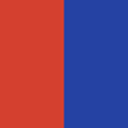

In [26]:
print(canvas_still.status, getattr(canvas_still.result, 'size', None), canvas_still.error) if canvas_still else print('Canvas unavailable in this renderer.')
if canvas_still and canvas_still.status == 'completed':
    print('Canvas pixel (4, 4):', canvas_still.result.getpixel((4, 4)))
    display(canvas_still.result.resize((128, 128)))


In [27]:
canvas_saved = export_canvas(canvas_ref) if canvas_ref else None

In [28]:
print(canvas_saved.status, canvas_saved.media, canvas_saved.error) if canvas_saved else print('Canvas unavailable in this renderer.')

completed {'media_id': 'R3aeBPJBo8u4oN7xsb1iDCRbR1BCa8BF', 'mime_type': 'image/png', 'bytes': 193, 'sha256': '86288e0fa1dc75499ca89bc4c9aa63a44ad6c8981502445adf1f14a9d123f175', 'expires_at': 1790672576.961282, 'width': 64, 'height': 32, 'path': 'media/capture-8a1c235df288d253.png'} None


In [29]:
canvas_source = start_canvas(canvas_ref, frame_rate=12) if canvas_ref else None

In [30]:
print(canvas_source.status, canvas_source.result, canvas_source.error) if canvas_source else print('Canvas unavailable in this renderer.')
print('The cleanup cell below stops an opened source through the shared source control.')

completed {'source_id': '[opaque hardware reference]', 'kind': 'canvas', 'video': True, 'audio': False, 'requested_frame_rate': 12, 'actual_frame_rate': 12, 'width': 64, 'height': 32, 'note': 'Canvas frames may be throttled when the notebook is in the background.'} None
The cleanup cell below stops an opened source through the shared source control.


## Capture a supported visible output region

Scroll so the raster output below is completely visible. The region includes its displayed output rectangle only, not code or inputs. Unsupported or partly hidden output is an explicit error.

In [31]:
display(Image(data=PNG_BYTES))

In [32]:
region = capture_notebook_region(['region-raster'])

completed (8, 8) None


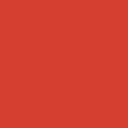

In [33]:
print(region.status, getattr(region.result, 'size', None), region.error)
if region.status == 'completed':
    display(region.result.resize((128, 128)))


In [34]:
if canvas_source and canvas_source.result and canvas_source.result.get('source_id'):
    stopped_source = stop_source(canvas_source.result['source_id'])
released_outputs = {}
seen_media_ids = set()
for label, receipt in [
    ('raster export', raster_export), ('vector export', vector_export),
    ('data export', data_export), ('saved data', data_saved),
    ('canvas still', canvas_still), ('canvas export', canvas_saved),
    ('region', region),
]:
    descriptor = receipt.media if receipt and receipt.status == 'completed' else None
    media_id = descriptor.get('media_id') if isinstance(descriptor, dict) else None
    if media_id and media_id not in seen_media_ids:
        seen_media_ids.add(media_id)
        released_outputs[label] = release_media(media_id)
for receipt in (data_saved, canvas_saved):
    descriptor = receipt.media if receipt and receipt.status == 'completed' else None
    if isinstance(descriptor, dict) and descriptor.get('path'):
        saved_path = Path.cwd() / descriptor['path']
        if saved_path.is_file() and hashlib.sha256(saved_path.read_bytes()).hexdigest() == descriptor['sha256']:
            saved_path.unlink()
print('Requested release for', len(released_outputs), 'owned outputs; removed matching generated files.')


Requested release for 7 owned outputs; removed matching generated files.


In [35]:
print('Canvas source:', stopped_source.status, stopped_source.error) if 'stopped_source' in globals() else print('No canvas source to stop.')
for label, receipt in released_outputs.items():
    print('Release', label, receipt.status, receipt.error)


Canvas source: completed None
Release raster export completed None
Release vector export completed None
Release data export completed None
Release saved data completed None
Release canvas still completed None
Release canvas export completed None
Release region completed None


## Ask ChatGPT about the live outputs

Run these questions one at a time. Each browser action first returns an operation ID and a running or waiting state; run its later status question after the media row completes before using its output ID, canvas ID, source ID, or managed media ID. Select text for the selection question. Near the region question, execute the adjacent disposable raster cell and keep its output fully visible.


Use &`read_notebook_view` for this open notebook. Report only its immediate operation ID/state; the later status question will describe the view.


Operation ID: `XowX_enOFlsf6UUOIAKpNirMhx-cF5E8` — running.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `read_notebook_view` | receipt accepted | {} | {"operation_id":"XowX_enOFlsf6UUOIAKpNirMhx-cF5E8","status":"running"} |


Use &`operation_status` on the preceding `read_notebook_view` operation ID after its media row completes. Report the actual notebook and active-cell facts; if still running, stop and retry later.


The notebook has 68 cells. The active cell is `source-stop-inspect` (index 39), also the only selected cell. It’s in command mode; four cells are visible, from `outputs-cleanup` to `outputs-ai-view-selection`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"XowX_enOFlsf6UUOIAKpNirMhx-cF5E8"} | {"operation_id":"XowX_enOFlsf6UUOIAKpNirMhx-cF5E8","status":"completed","result":{"active_cell_id":"source-stop-inspect","active_cell_index":39,"selected_cell_ids":["source-stop-inspect"],"selected_truncated":false,"visible":{"first":"outputs-cleanup","last":"outputs-ai-view-selection","count":4},"mode":"command","cell_count":68}} |


Use &`read_selection` with `max_chars=120` for text I selected in this editor. Report the immediate operation ID/state, not selected text yet.


Operation ID: `4TfxpoWpFln1caDMFhuZ_huo4XJQzma1` — running.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `read_selection` | receipt accepted | {"max_chars":120} | {"operation_id":"4TfxpoWpFln1caDMFhuZ_huo4XJQzma1","status":"running"} |


Use &`operation_status` on that `read_selection` operation ID. Quote only the actual bounded selected text, or report an empty selection honestly.


The selection is empty.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"4TfxpoWpFln1caDMFhuZ_huo4XJQzma1"} | {"operation_id":"4TfxpoWpFln1caDMFhuZ_huo4XJQzma1","status":"completed","result":{"cell_id":null,"text":"","truncated":false}} |


Use &`list_outputs` for `output-text` without rerunning it. Report its immediate operation ID/state; do not invent an output ID before completion.


Operation ID: `xLseziQPPEs6_AUgLX7_3PP3JRGgOVPM` — running.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `list_outputs` | receipt accepted | {"cell_id":"output-text"} | {"operation_id":"xLseziQPPEs6_AUgLX7_3PP3JRGgOVPM","status":"running"} |


Use &`operation_status` on that `list_outputs` operation ID after completion. Report the actual output ID, revision, and MIME type; if still running, retry later.


`output-text` has output ID `55dc7920f34e5de633de570e694c7a46`, revision `0`, and MIME type `text/plain`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"xLseziQPPEs6_AUgLX7_3PP3JRGgOVPM"} | {"operation_id":"xLseziQPPEs6_AUgLX7_3PP3JRGgOVPM","status":"completed","result":{"outputs":[{"cell_id":"output-text","output_id":"55dc7920f34e5de633de570e694c7a46","revision":0,"mime_types":["text/plain"],"output_type":"stream"}],"next_cursor":null}} |


Use &`read_output` on the exact cell ID, output ID, and revision in $`text_ref`, with `max_chars=120`. Report its immediate operation ID/state, not the text yet.


Operation ID: `6oRikkpO4o31I400ioMyy-lvhCSN5nRC` — running.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `read_output` | receipt accepted | {"cell_id":"output-text","output_id":"55dc7920f34e5de633de570e694c7a46","revision":0,"max_chars":120} | {"operation_id":"6oRikkpO4o31I400ioMyy-lvhCSN5nRC","status":"running"} |


Use &`operation_status` on that `read_output` operation ID after completion. Quote the returned short text and MIME type, or report the actual error.


MIME type: `text/plain`. Text: “Existing output text: red square and blue vector”

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"6oRikkpO4o31I400ioMyy-lvhCSN5nRC"} | {"operation_id":"6oRikkpO4o31I400ioMyy-lvhCSN5nRC","status":"completed","result":{"cell_id":"output-text","output_id":"55dc7920f34e5de633de570e694c7a46","revision":0,"mime":"text/plain","text":"Existing output text: red square and blue vector\n","start":0,"next_start":null,"total_chars":49}} |


Use &`export_output` on the exact cell ID, output ID, and revision in $`raster_ref`, with `save_to=None`. Report the immediate operation ID/state; no file should be written.


Operation ID: `M4nwCCq18U20V-ahgYHIbKjCXOXgsr7B` — running.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `export_output` | receipt accepted | {"cell_id":"output-raster","output_id":"6b859082defe8b90b9bc44def78142b1","revision":0} | {"operation_id":"M4nwCCq18U20V-ahgYHIbKjCXOXgsr7B","status":"running"} |


Use &`operation_status` on that `export_output` operation ID after completion. Report actual image dimensions, MIME type, SHA-256, and managed media ID if provided; do not put pixels in text.


Export completed: 8 × 8 PNG (`image/png`); SHA-256 `269661e8dbcb389941d2a1c41323776fac18a1ee3a08e9582a6c485291b53a88`; managed media ID `RpVgbq9HQKIR6bW41PD2vvsqmdma0XHz`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"M4nwCCq18U20V-ahgYHIbKjCXOXgsr7B"} | {"operation_id":"M4nwCCq18U20V-ahgYHIbKjCXOXgsr7B","status":"completed","media":{"media_id":"RpVgbq9HQKIR6bW41PD2vvsqmdma0XHz","mime_type":"image/png","bytes":77,"sha256":"269661e8dbcb389941d2a1c41323776fac18a1ee3a08e9582a6c485291b53a88","expires_at":1790672700.7872891,"width":8,"height":8}} |


Use &`list_canvases` on the exact cell ID, output ID, and revision in $`canvas_output_ref`. Report its immediate operation ID/state. If this renderer strips the canvas, do not claim one exists.


Operation ID: `kpcxzNn2fxix0XmgHaAnAgbkYQDsUiko` — running.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `list_canvases` | receipt accepted | {"cell_id":"output-canvas","output_id":"901fd9fe208475bd53667e2d19135720","revision":0} | {"operation_id":"kpcxzNn2fxix0XmgHaAnAgbkYQDsUiko","status":"running"} |


Use &`operation_status` on the prior `list_canvases` operation ID. Report the actual canvas ID/descriptor only if completed; otherwise describe the real unsupported or pending result.


Canvas ID: `ef15ce71fe1bc1088ac9c8d33894f10d` (`output-canvas`, output `901fd9fe208475bd53667e2d19135720`, revision 0, view revision 0; 64 × 32).

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"kpcxzNn2fxix0XmgHaAnAgbkYQDsUiko"} | {"operation_id":"kpcxzNn2fxix0XmgHaAnAgbkYQDsUiko","status":"completed","result":{"available":true,"canvases":[{"cell_id":"output-canvas","output_id":"901fd9fe208475bd53667e2d19135720","revision":0,"canvas_id":"ef15ce71fe1bc1088ac9c8d33894f10d","view_revision":0,"width":64,"height":32}],"next_cursor":null}} |


If the preceding status returned a supported canvas, use &`capture_canvas` on that exact descriptor. Report only its immediate operation ID/state; otherwise stop without making up a canvas.


Operation ID: `0ZAJG3N9kNq0W5nhPi0NzPM218_zM3w6` — running.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `capture_canvas` | receipt accepted | {"canvas":{"canvas_id":"ef15ce71fe1bc1088ac9c8d33894f10d","cell_id":"output-canvas","output_id":"901fd9fe208475bd53667e2d19135720","revision":0,"view_revision":0,"width":64,"height":32}} | {"operation_id":"0ZAJG3N9kNq0W5nhPi0NzPM218_zM3w6","status":"running"} |


Use &`operation_status` on the `capture_canvas` operation ID after completion. Report actual dimensions, encoded hash, and managed media ID if returned; the direct Python inspection above shows the sampled pixel. If still running or unsupported, say so.


Canvas capture completed: 64 × 32 PNG. SHA-256: `86288e0fa1dc75499ca89bc4c9aa63a44ad6c8981502445adf1f14a9d123f175`. Managed media ID: `wIblBdT8vb4nepK5KtOgxCTLfO4n3UEw`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"0ZAJG3N9kNq0W5nhPi0NzPM218_zM3w6"} | {"operation_id":"0ZAJG3N9kNq0W5nhPi0NzPM218_zM3w6","status":"completed","media":{"media_id":"wIblBdT8vb4nepK5KtOgxCTLfO4n3UEw","mime_type":"image/png","bytes":193,"sha256":"86288e0fa1dc75499ca89bc4c9aa63a44ad6c8981502445adf1f14a9d123f175","expires_at":1790672754.045318,"width":64,"height":32}} |


If a supported canvas descriptor was verified above, use &`export_canvas` on it with `save_to=None`. Report the immediate operation ID/state; otherwise stop without claiming a file or image.


Operation ID: `F6-YNsiAQhxOwOSUrxL5gyjm5eLijzXY` — running.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `export_canvas` | receipt accepted | {"canvas":{"canvas_id":"ef15ce71fe1bc1088ac9c8d33894f10d","cell_id":"output-canvas","output_id":"901fd9fe208475bd53667e2d19135720","revision":0,"view_revision":0},"save_to":null} | {"operation_id":"F6-YNsiAQhxOwOSUrxL5gyjm5eLijzXY","status":"running"} |


Use &`operation_status` on that `export_canvas` operation ID after completion. Report actual image dimensions, hash, and managed media ID if returned; this in-memory request writes no file.


Canvas export completed in memory: 64 × 32 PNG; SHA-256 `86288e0fa1dc75499ca89bc4c9aa63a44ad6c8981502445adf1f14a9d123f175`; managed media ID `LLe0rl3jMbQOXTmnL8mwA92c_BZLdOe9`. No file was written.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"F6-YNsiAQhxOwOSUrxL5gyjm5eLijzXY"} | {"operation_id":"F6-YNsiAQhxOwOSUrxL5gyjm5eLijzXY","status":"completed","media":{"media_id":"LLe0rl3jMbQOXTmnL8mwA92c_BZLdOe9","mime_type":"image/png","bytes":193,"sha256":"86288e0fa1dc75499ca89bc4c9aa63a44ad6c8981502445adf1f14a9d123f175","expires_at":1790672782.5200288,"width":64,"height":32}} |


If a supported canvas descriptor was verified above, use &`start_canvas` at 12 frames per second. Report only its immediate operation ID/state; otherwise stop.


Operation ID: `snkrUPcGyEeOXfgHDTRlYumITbabd-Ov` — running.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `start_canvas` | receipt accepted | {"canvas":{"cell_id":"output-canvas","output_id":"901fd9fe208475bd53667e2d19135720","revision":0,"view_revision":0,"canvas_id":"ef15ce71fe1bc1088ac9c8d33894f10d","width":64,"height":32},"frame_rate":12} | {"operation_id":"snkrUPcGyEeOXfgHDTRlYumITbabd-Ov","status":"running"} |


Use &`operation_status` on the `start_canvas` operation ID. Report the actual source ID only if completed; otherwise stop and retry later.


Canvas source ID: `[private device detail]`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"snkrUPcGyEeOXfgHDTRlYumITbabd-Ov"} | {"operation_id":"snkrUPcGyEeOXfgHDTRlYumITbabd-Ov","status":"completed","result":{"source_id":"[opaque hardware reference]","kind":"canvas","video":true,"audio":false,"requested_frame_rate":12,"actual_frame_rate":12,"width":64,"height":32,"note":"Canvas frames may be throttled when the notebook is in the background."}} |


Use &`stop_source` only on the exact canvas source ID verified in the previous status. Report its immediate stop operation ID/state.


Stop operation ID: `A3AelkK-K1Kd30EKkWuDJSUW-pStcyCB` — running.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `stop_source` | receipt accepted | {"source_id":"[opaque hardware reference]"} | {"operation_id":"A3AelkK-K1Kd30EKkWuDJSUW-pStcyCB","status":"running"} |


Use &`operation_status` on the preceding canvas `stop_source` operation ID. Confirm the canvas source actually stopped before continuing to region capture or release; if still active, stop and retry later.


Confirmed: canvas source `[private device detail]` stopped successfully.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"A3AelkK-K1Kd30EKkWuDJSUW-pStcyCB"} | {"operation_id":"A3AelkK-K1Kd30EKkWuDJSUW-pStcyCB","status":"completed","result":{"source_id":"[opaque hardware reference]","stopped":true}} |


### Keep the AI region output visible

Run the next disposable cell now. Keep its small PNG output visible beside the AI question that follows; the earlier direct-example raster is farther up the notebook.


In [36]:
display(Image(data=PNG_BYTES))


After running the adjacent `region-ai-raster` code cell, keep its 8×8 output fully visible while asking this question. Use &`capture_notebook_region` with `cell_ids=["region-ai-raster"]` and `save_to=None`. Report only the immediate operation ID/state; do not capture other content or target the earlier direct-example raster.


Operation ID: `2oxnbrK2A7pFdLirEHxeyFT5qPCluCyI` — running.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `capture_notebook_region` | receipt accepted | {"cell_ids":["region-ai-raster"],"save_to":null} | {"operation_id":"2oxnbrK2A7pFdLirEHxeyFT5qPCluCyI","status":"running"} |


Use &`operation_status` on the prior region-capture operation ID after completion. Report actual dimensions and managed media ID, or a concrete visibility error, without inventing pixels.


Region capture completed: 8 × 8 pixels. Managed media ID: `7z8mBc-y4phUfJ5XNdVoSCyal_Xvoyik`.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"2oxnbrK2A7pFdLirEHxeyFT5qPCluCyI"} | {"operation_id":"2oxnbrK2A7pFdLirEHxeyFT5qPCluCyI","status":"completed","media":{"media_id":"7z8mBc-y4phUfJ5XNdVoSCyal_Xvoyik","mime_type":"image/png","bytes":111,"sha256":"6fbb2ba48d5acf2c215567197a8e664070e666121bd960363f3d0df1a602828f","expires_at":1790672859.1097229,"width":8,"height":8}} |


Use &`release_media` only on exact managed media IDs reported by completed AI export, canvas capture/export, and region-capture statuses above. Report each release operation ID/state. Skip missing IDs rather than guessing. Saved notebook displays remain visible.


All four releases succeeded:
- Raster: `2g3sYVZ4cRGBnNzRDMI6D6Y9p0QFj4rY` — released
- Canvas capture: `3krOkauOhrGvxVFR9cxxioCzVvfEiXj4` — released
- Canvas export: `aGT5q7GbuiO1frLhjSEGykGojzXMm6wq` — released
- Region capture: `Y1WqyIQdOa7EYVS-SZpoDZvlFdU0E7zv` — released

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `release_media` | completed | {"media_id":"RpVgbq9HQKIR6bW41PD2vvsqmdma0XHz"} | {"operation_id":"2g3sYVZ4cRGBnNzRDMI6D6Y9p0QFj4rY","released":true} |
| `release_media` | completed | {"media_id":"wIblBdT8vb4nepK5KtOgxCTLfO4n3UEw"} | {"operation_id":"3krOkauOhrGvxVFR9cxxioCzVvfEiXj4","released":true} |
| `release_media` | completed | {"media_id":"LLe0rl3jMbQOXTmnL8mwA92c_BZLdOe9"} | {"operation_id":"aGT5q7GbuiO1frLhjSEGykGojzXMm6wq","released":true} |
| `release_media` | completed | {"media_id":"7z8mBc-y4phUfJ5XNdVoSCyal_Xvoyik"} | {"operation_id":"Y1WqyIQdOa7EYVS-SZpoDZvlFdU0E7zv","released":true} |


After the release rows finish, use &`operation_status` on each exact release operation ID from the prior answer. Report actual terminal states; do not claim release from initial snapshots.


All four releases completed with `released: true`: raster, canvas capture, canvas export, and region capture.

**Observed live tool calls for the answer above** (actual subscription events; private fields shortened).

| Tool | Result state | Submitted arguments | Observed result |
| --- | --- | --- | --- |
| `operation_status` | completed | {"operation_id":"2g3sYVZ4cRGBnNzRDMI6D6Y9p0QFj4rY"} | {"operation_id":"2g3sYVZ4cRGBnNzRDMI6D6Y9p0QFj4rY","status":"completed","result":{"released":true}} |
| `operation_status` | completed | {"operation_id":"3krOkauOhrGvxVFR9cxxioCzVvfEiXj4"} | {"operation_id":"3krOkauOhrGvxVFR9cxxioCzVvfEiXj4","status":"completed","result":{"released":true}} |
| `operation_status` | completed | {"operation_id":"aGT5q7GbuiO1frLhjSEGykGojzXMm6wq"} | {"operation_id":"aGT5q7GbuiO1frLhjSEGykGojzXMm6wq","status":"completed","result":{"released":true}} |
| `operation_status` | completed | {"operation_id":"Y1WqyIQdOa7EYVS-SZpoDZvlFdU0E7zv"} | {"operation_id":"Y1WqyIQdOa7EYVS-SZpoDZvlFdU0E7zv","status":"completed","result":{"released":true}} |


## Read a selected line

The first selection example above returned an empty result. Run the next call cell, then during its five-second preparation interval click the `selection-normal-target` editor and select its entire `SELECT_ME = "blue square"` line. Keep that editor focused until the call returns. Starting the call before selecting matters: running a cell can change editor focus. The delay gives you time to make an ordinary JupyterLab selection; it does not wait for a browser receipt. If you miss the interval, rerun the call and select again.


In [ ]:
SELECT_ME = "blue square"
SELECT_ME


In [ ]:
import asyncio
await asyncio.sleep(5)  # Select the SELECT_ME line in selection-normal-target now.
selected_text = read_selection(max_chars=120)
selected_text


In [ ]:
print("Selected text:", selected_text.status, selected_text.result, selected_text.error)
if selected_text.status == "completed":
    assert selected_text.result["cell_id"] == "selection-normal-target"
    assert selected_text.result["text"] == 'SELECT_ME = "blue square"', "Rerun the call, then select the line during its preparation interval."


### Ask AI about a live selection

Run the next small fixture once. Start the AI question below it, then promptly click its editor and select **selected blue square** while the tool request is pending. Keep the selection focused until the tool reports an operation ID. The model must report the actual result from the later status question, not copy these words from notebook source. If it reads an empty selection, retry with the editor focused.


In [ ]:
AI_SELECTION_EXAMPLE = "selected blue square"
AI_SELECTION_EXAMPLE


Use &`read_selection` with `max_chars=120` for the text I select in the `selection-ai-target` editor immediately after starting this question. Report the immediate operation ID and state only; do not infer selected text from the fixture source.


Use &`operation_status` on the preceding `read_selection` operation ID. If completed, quote its actual `cell_id` and selected text. If it is still running or empty, report that state honestly so I can retry with the editor focused.
